# Bike embeddings: extensiones didacticas

Este notebook conserva la idea del ejemplo original, pero agrega variantes para comparar como cambia el embedding aprendido cuando:
- cambia la inicializacion;
- cambia la variable categorica;
- cambia el target;
- cambia la dimension del embedding.

La idea no es optimizar performance, sino mostrar que los embeddings dependen de la tarea y del contexto de entrenamiento.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler

plt.style.use("seaborn-v0_8-whitegrid")

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
DATA_CANDIDATES = [
    Path("bike_sharing_daily.csv"),
    Path("clase_7/jupyter_notebooks/bike_sharing_daily.csv"),
    Path("/content/bike_sharing_daily.csv"),
]

data_path = next((path for path in DATA_CANDIDATES if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("No encontre bike_sharing_daily.csv en las rutas esperadas.")

print(f"Archivo cargado desde: {data_path}")
df = pd.read_csv(data_path)
df["dteday"] = pd.to_datetime(df["dteday"])
df.head(3)

Archivo cargado desde: bike_sharing_daily.csv


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349


## Variables disponibles

Vamos a trabajar principalmente con:
- categoricas: `mnth`, `weekday`, `season`
- continuas: `hum`, `temp`, `windspeed`
- targets: `cnt`, `casual`, `registered`

In [3]:
meses = [
    "enero", "febrero", "marzo", "abril", "mayo", "junio",
    "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre",
]
weekdays = ["domingo", "lunes", "martes", "miercoles", "jueves", "viernes", "sabado"]
seasons = ["primavera", "verano", "otoño", "invierno"]

label_maps = {
    "mnth": meses,
    "weekday": weekdays,
    "season": seasons,
}

df[["mnth", "weekday", "season", "temp", "hum", "windspeed", "casual", "registered", "cnt"]].head()

,mnth,weekday,season,temp,hum,windspeed,casual,registered,cnt
0,1,6,1,0.344167,0.805833,0.160446,331,654,985
1,1,0,1,0.363478,0.696087,0.248539,131,670,801
2,1,1,1,0.196364,0.437273,0.248309,120,1229,1349
3,1,2,1,0.200000,0.590435,0.160296,108,1454,1562
4,1,3,1,0.226957,0.436957,0.186900,82,1518,1600


## Utilidades

La siguiente funcion entrena un pequeno regressor con una capa `Embedding` y devuelve:
- el embedding inicial;
- el embedding final;
- la historia de la loss;
- un resumen de medias por categoria para ayudar a interpretar el scatter.

In [4]:
class CategoryEmbeddingRegressor(nn.Module):
    def __init__(self, n_numeric, vocab_size, embedding_dim=2, init_mode="same_point"):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(n_numeric + embedding_dim, 1)

        if init_mode == "same_point":
            with torch.no_grad():
                self.embeddings.weight.fill_(0.0)
        elif init_mode == "small_random":
            nn.init.normal_(self.embeddings.weight, mean=0.0, std=0.05)
        elif init_mode == "random":
            pass
        else:
            raise ValueError(f"Modo de inicializacion no soportado: {init_mode}")

    def forward(self, x_num, cat_idx):
        embeds = self.embeddings(cat_idx).view((1, -1))
        final_input = torch.cat([x_num, embeds], dim=1)
        return self.linear(final_input)


def run_embedding_experiment(
    df,
    category_col,
    numeric_cols,
    target_col,
    label_names,
    embedding_dim=2,
    init_mode="same_point",
    epochs=50,
    lr=0.05,
):
    work_df = df[[category_col, *numeric_cols, target_col]].copy()
    scaler = MinMaxScaler()
    work_df["target_scaled"] = scaler.fit_transform(work_df[[target_col]])

    x_y = work_df[[category_col, *numeric_cols, "target_scaled"]].to_numpy(dtype=np.float32)
    unique_categories = sorted(work_df[category_col].unique())
    cat_to_ix = {cat: i for i, cat in enumerate(unique_categories)}

    model = CategoryEmbeddingRegressor(
        n_numeric=len(numeric_cols),
        vocab_size=len(unique_categories),
        embedding_dim=embedding_dim,
        init_mode=init_mode,
    )
    optimizer = optim.SGD(model.parameters(), lr=lr)
    loss_function = nn.MSELoss()

    emb_init = np.copy(model.embeddings.weight.detach().numpy())
    losses = []

    for epoch in range(epochs):
        total_loss = 0.0
        for indice in np.random.permutation(len(x_y)):
            cat_value = int(x_y[indice, 0])
            cat_idx = torch.tensor(cat_to_ix[cat_value], dtype=torch.long)
            x_num = torch.tensor([x_y[indice, 1:-1]], dtype=torch.float32)
            target = torch.tensor([[x_y[indice, -1]]], dtype=torch.float32)

            model.zero_grad()
            pred = model(x_num, cat_idx)
            loss = loss_function(pred.float(), target.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        losses.append(total_loss / len(x_y))

    emb_final = model.embeddings.weight.detach().numpy()
    summary = (
        df.groupby(category_col)[target_col]
        .mean()
        .reindex(unique_categories)
        .reset_index(name="target_mean")
    )
    summary["label"] = label_names

    return {
        "model": model,
        "losses": losses,
        "emb_init": emb_init,
        "emb_final": emb_final,
        "summary": summary,
        "cat_to_ix": cat_to_ix,
        "category_col": category_col,
        "numeric_cols": numeric_cols,
        "target_col": target_col,
    }


def plot_embedding_result(result, title, cmap="viridis"):
    emb_init = result["emb_init"]
    emb_final = result["emb_final"]
    summary = result["summary"]

    if emb_final.shape[1] != 2:
        raise ValueError("Esta funcion de visualizacion espera embeddings de dimension 2.")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(result["losses"], color="tab:blue")
    axes[0].set_title("Curva de entrenamiento")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("MSE medio")

    scatter = axes[1].scatter(
        emb_final[:, 0],
        emb_final[:, 1],
        c=summary["target_mean"],
        cmap=cmap,
        s=130,
        edgecolor="black",
    )
    axes[1].scatter(
        emb_init[:, 0],
        emb_init[:, 1],
        s=110,
        facecolors="none",
        edgecolors="gray",
        linewidths=1.5,
    )

    for i, row in summary.iterrows():
        axes[1].plot(
            [emb_init[i, 0], emb_final[i, 0]],
            [emb_init[i, 1], emb_final[i, 1]],
            color="gray",
            alpha=0.5,
        )
        axes[1].text(emb_final[i, 0] + 0.001, emb_final[i, 1] + 0.001, row["label"], fontsize=10)

    axes[1].set_title(title)
    axes[1].set_xlabel("emb 0")
    axes[1].set_ylabel("emb 1")
    plt.colorbar(scatter, ax=axes[1], label="target promedio")
    plt.tight_layout()
    plt.show()


def print_linear_weights(result, experiment_name):
    weights = result["model"].linear.weight.detach().numpy().ravel()
    bias = float(result["model"].linear.bias.detach().numpy()[0])
    feature_names = list(result["numeric_cols"]) + [f"emb_{i}" for i in range(result["emb_final"].shape[1])]

    print(f"Pesos lineales - {experiment_name}")
    for name, weight in zip(feature_names, weights):
        print(f"  {name}: {weight:.6f}")
    print(f"  bias: {bias:.6f}")
    print()


def plot_embedding_table(result):
    display(result["summary"][["label", "target_mean"]])

## Experimento A: misma tarea, distinta inicializacion

Comparamos:
- `same_point`: todos los embeddings arrancan igual;
- `small_random`: todos arrancan cerca del origen, pero con pequenas diferencias.

In [5]:
exp_same = run_embedding_experiment(
    df=df,
    category_col="mnth",
    numeric_cols=["hum"],
    target_col="cnt",
    label_names=meses,
    embedding_dim=2,
    init_mode="same_point",
)

exp_small_random = run_embedding_experiment(
    df=df,
    category_col="mnth",
    numeric_cols=["hum"],
    target_col="cnt",
    label_names=meses,
    embedding_dim=2,
    init_mode="small_random",
)

C:\Users\CIDIEE_NN\AppData\Local\Temp\ipykernel_6428\3534700081.py:59: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ..\torch\csrc\utils\tensor_new.cpp:248.)
  x_num = torch.tensor([x_y[indice, 1:-1]], dtype=torch.float32)


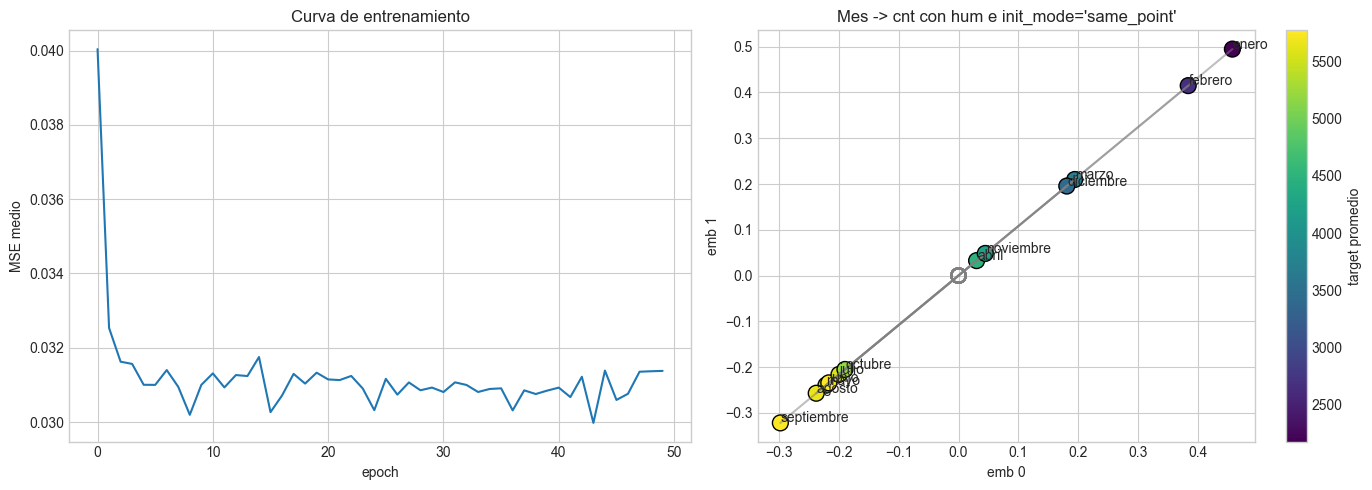

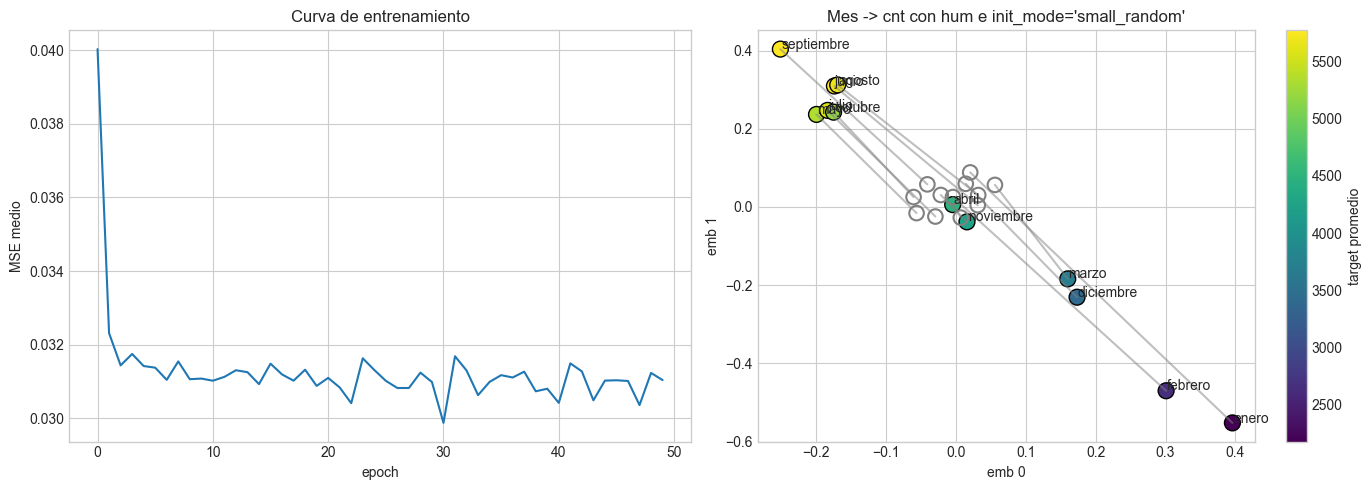

Pesos lineales - Experimento A - same_point
  hum: -0.387605
  emb_0: -0.255202
  emb_1: -0.275577
  bias: 0.684202

Pesos lineales - Experimento A - small_random
  hum: -0.366255
  emb_0: -0.242776
  emb_1: 0.353821
  bias: 0.724482



In [6]:
plot_embedding_result(exp_same, "Mes -> cnt con hum e init_mode='same_point'")
plot_embedding_result(exp_small_random, "Mes -> cnt con hum e init_mode='small_random'")

print_linear_weights(exp_same, "Experimento A - same_point")
print_linear_weights(exp_small_random, "Experimento A - small_random")

## Experimento B: cambia la variable categorica

Aca mantenemos el target `cnt`, pero cambiamos la variable a embeddear:
- `mnth`
- `weekday`
- `season`

In [7]:
exp_month = run_embedding_experiment(
    df=df,
    category_col="mnth",
    numeric_cols=["hum"],
    target_col="cnt",
    label_names=meses,
    embedding_dim=2,
    init_mode="same_point",
)

exp_weekday = run_embedding_experiment(
    df=df,
    category_col="weekday",
    numeric_cols=["hum"],
    target_col="cnt",
    label_names=weekdays,
    embedding_dim=2,
    init_mode="same_point",
)

exp_season = run_embedding_experiment(
    df=df,
    category_col="season",
    numeric_cols=["hum"],
    target_col="cnt",
    label_names=seasons,
    embedding_dim=2,
    init_mode="same_point",
)

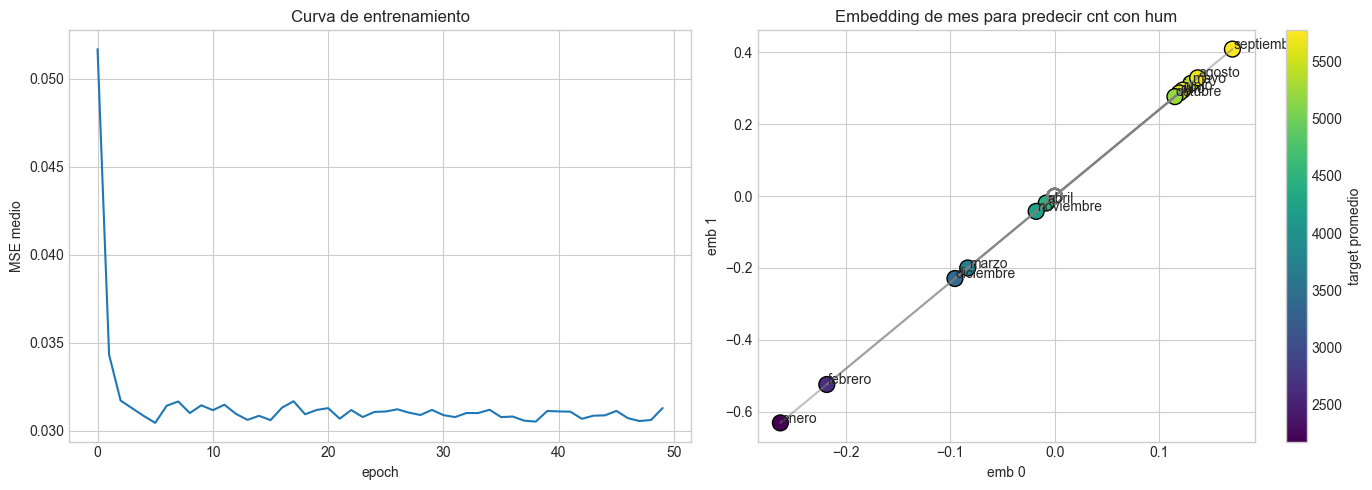

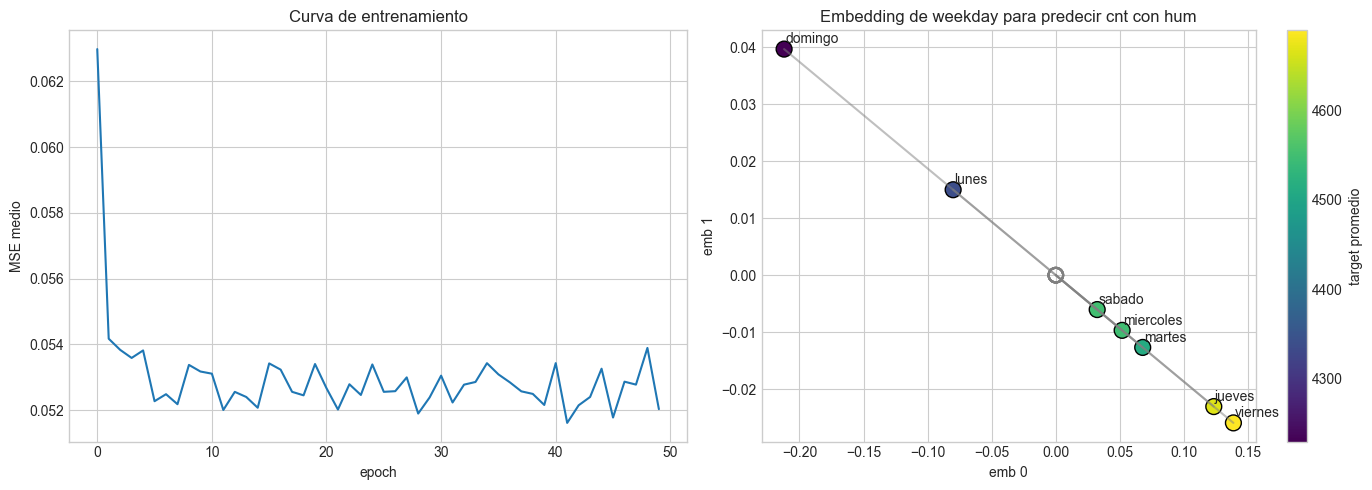

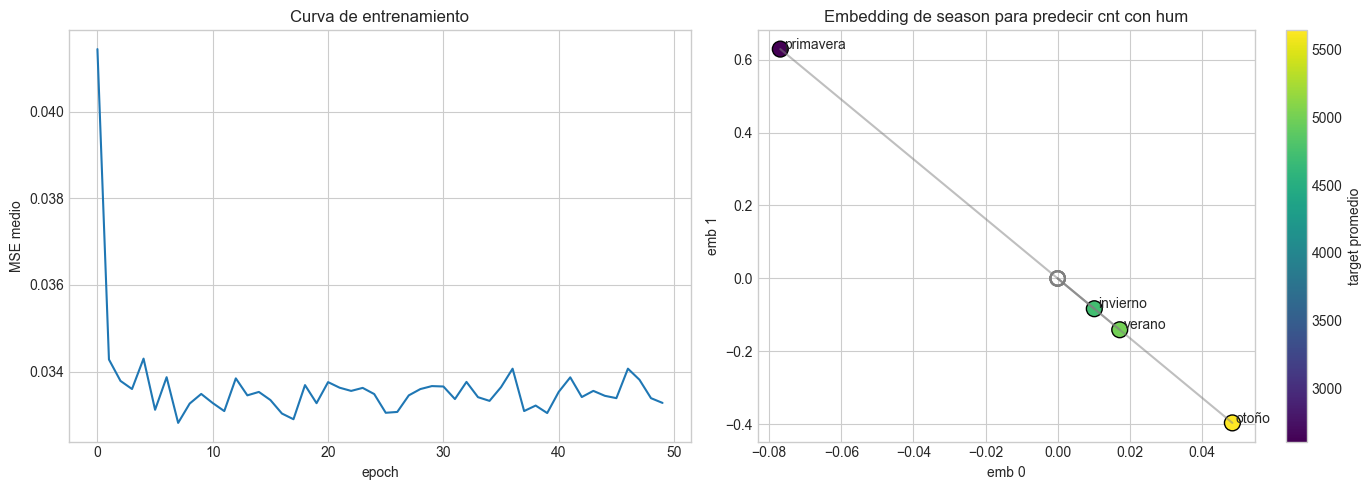

Pesos lineales - Experimento B - month
  hum: -0.348110
  emb_0: 0.140982
  emb_1: 0.338613
  bias: 0.721875

Pesos lineales - Experimento B - weekday
  hum: -0.223430
  emb_0: 0.081308
  emb_1: -0.015220
  bias: 0.557181

Pesos lineales - Experimento B - season
  hum: -0.326143
  emb_0: 0.046955
  emb_1: -0.383719
  bias: 0.698974



In [8]:
plot_embedding_result(exp_month, "Embedding de mes para predecir cnt con hum")
plot_embedding_result(exp_weekday, "Embedding de weekday para predecir cnt con hum")
plot_embedding_result(exp_season, "Embedding de season para predecir cnt con hum")

print_linear_weights(exp_month, "Experimento B - month")
print_linear_weights(exp_weekday, "Experimento B - weekday")
print_linear_weights(exp_season, "Experimento B - season")

## Experimento C: cambia el target

Ahora dejamos fijo `mnth` como categoria y comparamos tres tareas:
- predecir `cnt`
- predecir `casual`
- predecir `registered`

In [9]:
exp_cnt = run_embedding_experiment(
    df=df,
    category_col="mnth",
    numeric_cols=["hum"],
    target_col="cnt",
    label_names=meses,
    embedding_dim=2,
    init_mode="same_point",
)

exp_casual = run_embedding_experiment(
    df=df,
    category_col="mnth",
    numeric_cols=["hum"],
    target_col="casual",
    label_names=meses,
    embedding_dim=2,
    init_mode="same_point",
)

exp_registered = run_embedding_experiment(
    df=df,
    category_col="mnth",
    numeric_cols=["hum"],
    target_col="registered",
    label_names=meses,
    embedding_dim=2,
    init_mode="same_point",
)

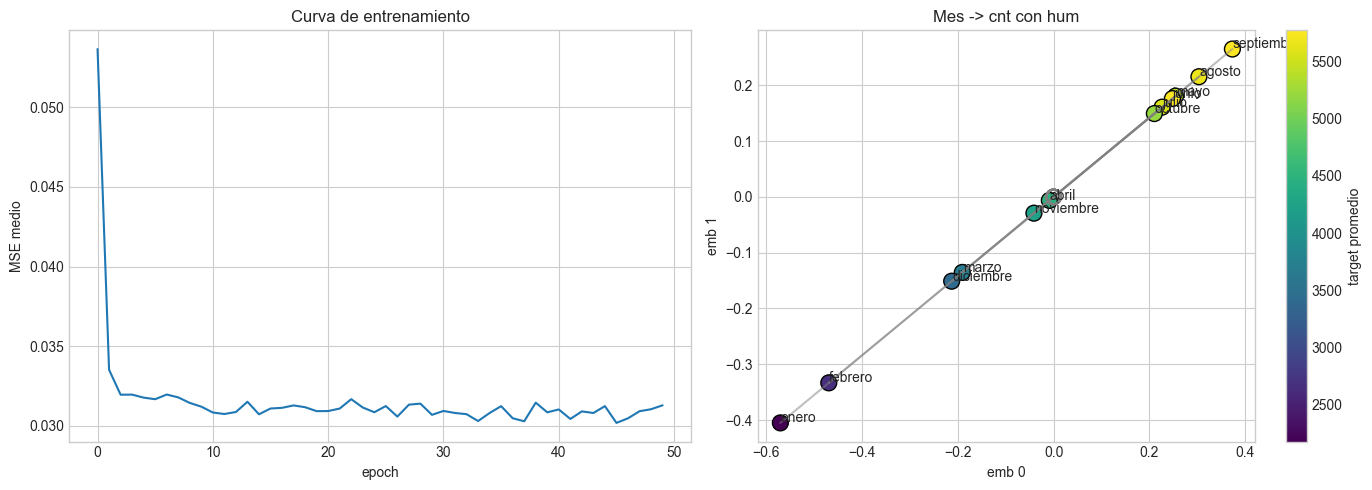

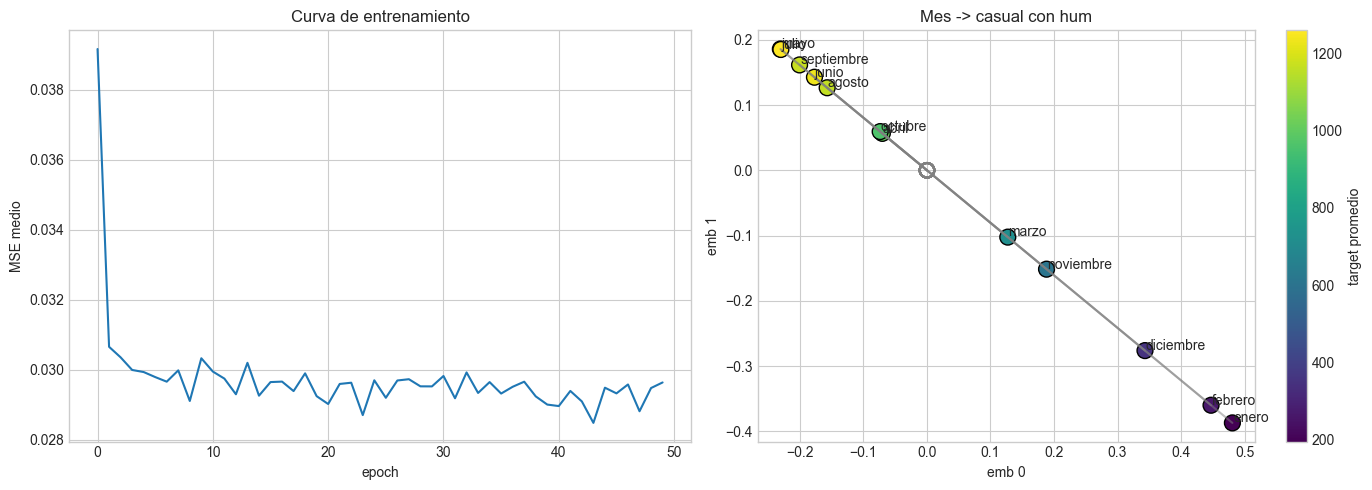

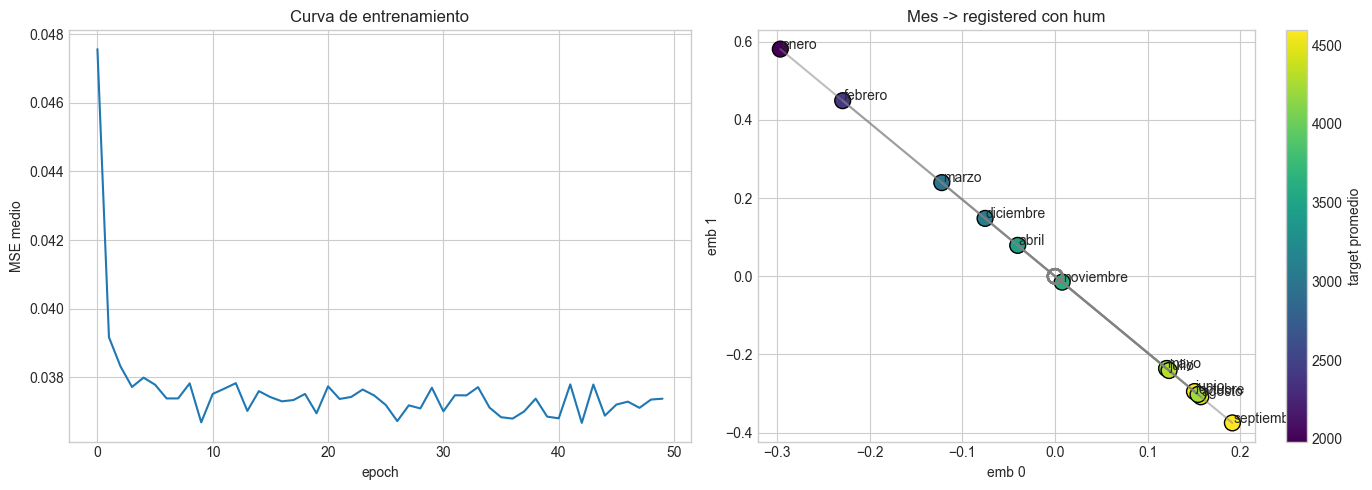

Pesos lineales - Experimento C - cnt
  hum: -0.331673
  emb_0: 0.308588
  emb_1: 0.219010
  bias: 0.714276

Pesos lineales - Experimento C - casual
  hum: -0.219256
  emb_0: -0.243680
  emb_1: 0.196162
  bias: 0.348579

Pesos lineales - Experimento C - registered
  hum: -0.374302
  emb_0: 0.147061
  emb_1: -0.288200
  bias: 0.680464



In [10]:
plot_embedding_result(exp_cnt, "Mes -> cnt con hum")
plot_embedding_result(exp_casual, "Mes -> casual con hum")
plot_embedding_result(exp_registered, "Mes -> registered con hum")

print_linear_weights(exp_cnt, "Experimento C - cnt")
print_linear_weights(exp_casual, "Experimento C - casual")
print_linear_weights(exp_registered, "Experimento C - registered")

## Experimento D: cambia la cantidad de informacion numerica

Mantenemos:
- categoria: `mnth`
- target: `cnt`

Pero comparamos cinco situaciones:
- solo `hum`
- solo `temp`
- solo `windspeed`
- `hum + temp`
- `hum + temp + windspeed`

Esto sirve para discutir cuanto contexto extra "le roba trabajo" al embedding.

In [11]:
exp_hum = run_embedding_experiment(
    df=df,
    category_col="mnth",
    numeric_cols=["hum"],
    target_col="cnt",
    label_names=meses,
    embedding_dim=2,
    init_mode="same_point",
)

exp_temp = run_embedding_experiment(
    df=df,
    category_col="mnth",
    numeric_cols=["temp"],
    target_col="cnt",
    label_names=meses,
    embedding_dim=2,
    init_mode="same_point",
)

exp_windspeed = run_embedding_experiment(
    df=df,
    category_col="mnth",
    numeric_cols=["windspeed"],
    target_col="cnt",
    label_names=meses,
    embedding_dim=2,
    init_mode="same_point",
)

exp_hum_temp = run_embedding_experiment(
    df=df,
    category_col="mnth",
    numeric_cols=["hum", "temp"],
    target_col="cnt",
    label_names=meses,
    embedding_dim=2,
    init_mode="same_point",
)

exp_hum_temp_wind = run_embedding_experiment(
    df=df,
    category_col="mnth",
    numeric_cols=["hum", "temp", "windspeed"],
    target_col="cnt",
    label_names=meses,
    embedding_dim=2,
    init_mode="same_point",
)

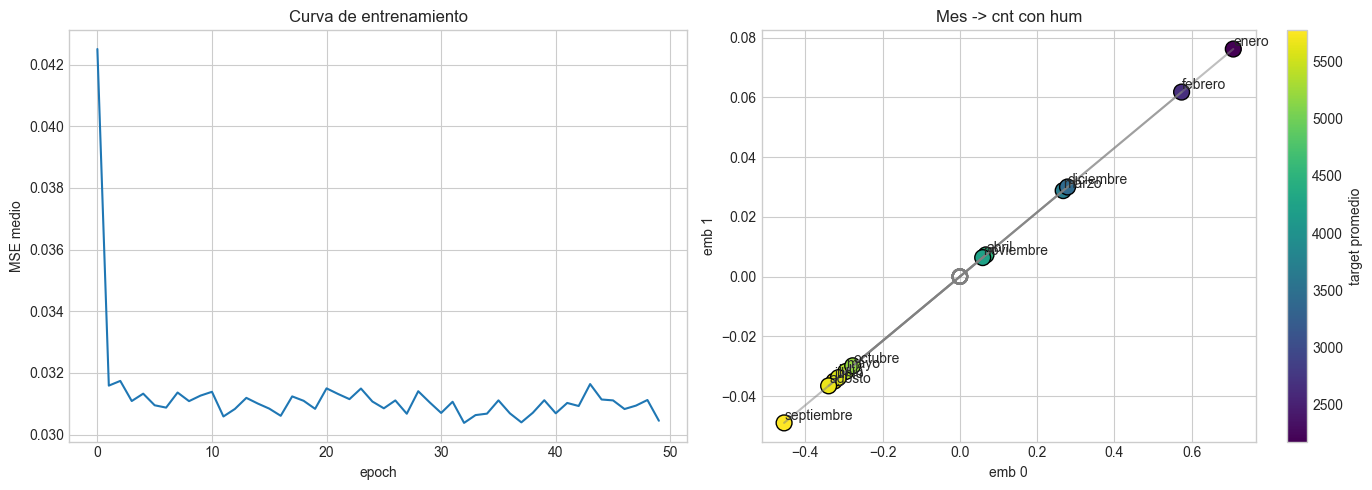

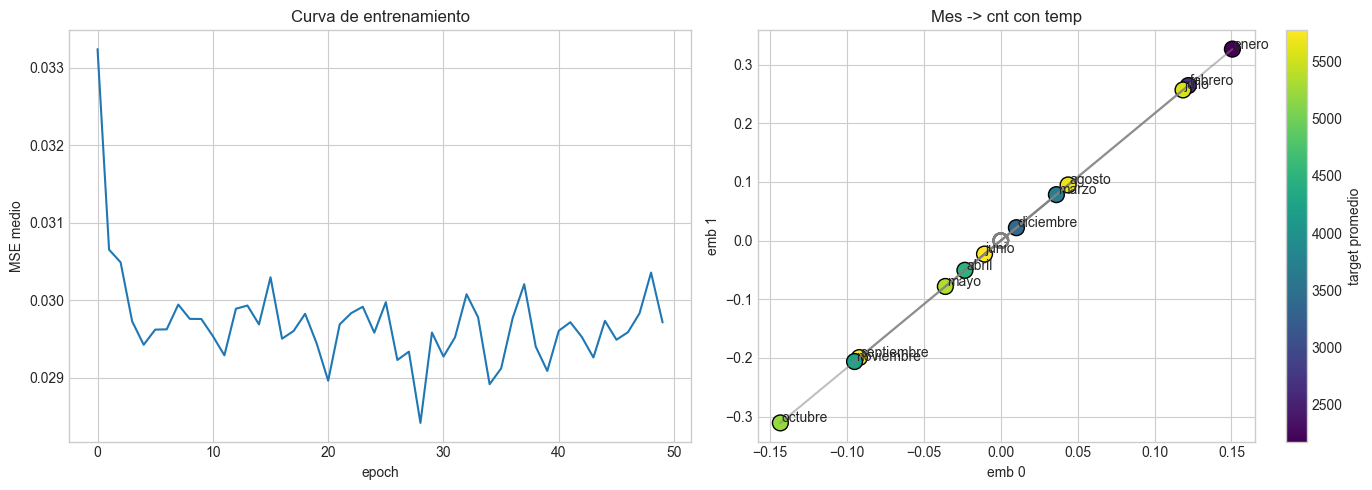

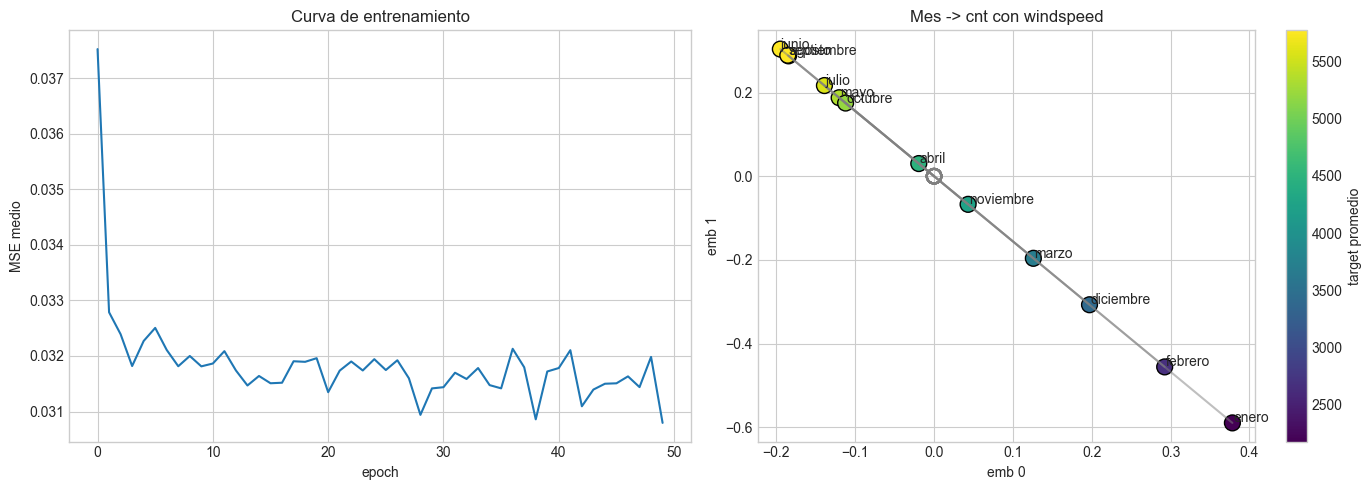

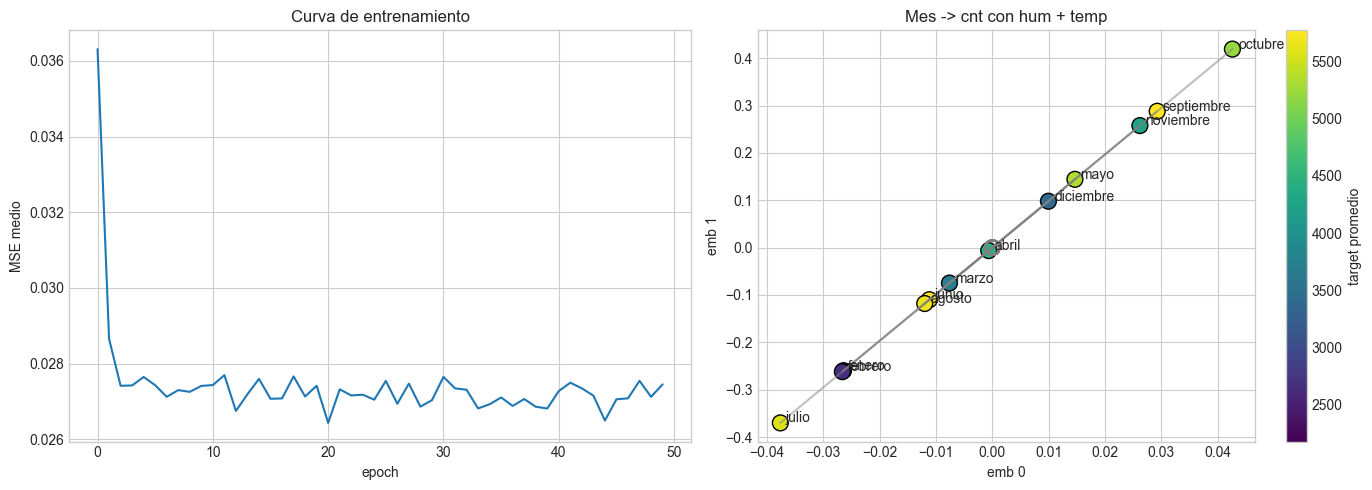

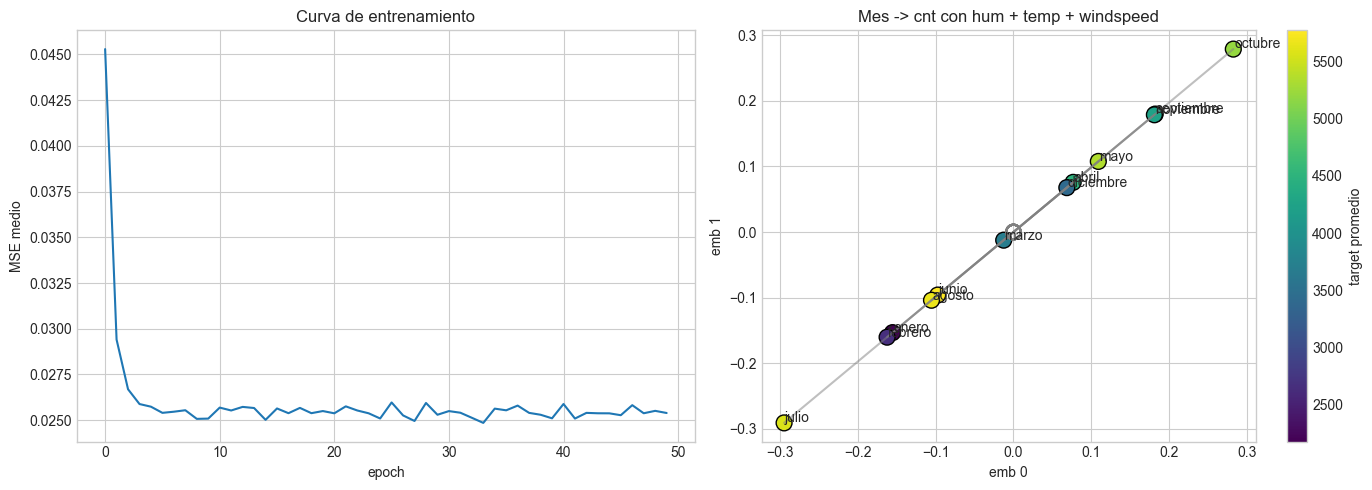

Pesos lineales - Experimento D - hum
  hum: -0.316246
  emb_0: -0.463544
  emb_1: -0.049897
  bias: 0.754327

Pesos lineales - Experimento D - temp
  temp: 0.731017
  emb_0: -0.103356
  emb_1: -0.223940
  bias: 0.202936

Pesos lineales - Experimento D - windspeed
  windspeed: -0.421218
  emb_0: -0.197863
  emb_1: 0.308309
  bias: 0.541527

Pesos lineales - Experimento D - hum + temp
  hum: -0.371954
  temp: 0.831678
  emb_0: 0.028995
  emb_1: 0.285381
  bias: 0.397691

Pesos lineales - Experimento D - hum + temp + windspeed
  hum: -0.522703
  temp: 0.815022
  windspeed: -0.541336
  emb_0: 0.200654
  emb_1: 0.198130
  bias: 0.478560



In [12]:
plot_embedding_result(exp_hum, "Mes -> cnt con hum")
plot_embedding_result(exp_temp, "Mes -> cnt con temp")
plot_embedding_result(exp_windspeed, "Mes -> cnt con windspeed")
plot_embedding_result(exp_hum_temp, "Mes -> cnt con hum + temp")
plot_embedding_result(exp_hum_temp_wind, "Mes -> cnt con hum + temp + windspeed")

print_linear_weights(exp_hum, "Experimento D - hum")
print_linear_weights(exp_temp, "Experimento D - temp")
print_linear_weights(exp_windspeed, "Experimento D - windspeed")
print_linear_weights(exp_hum_temp, "Experimento D - hum + temp")
print_linear_weights(exp_hum_temp_wind, "Experimento D - hum + temp + windspeed")

## Experimento E: cambia la dimension del embedding

Aca no cambiamos la tarea, solo la capacidad de la representacion.
Vamos a comparar:
- embedding de dimension 1
- embedding de dimension 2
- embedding de dimension 3

In [13]:
exp_dim1 = run_embedding_experiment(
    df=df,
    category_col="mnth",
    numeric_cols=["hum"],
    target_col="cnt",
    label_names=meses,
    embedding_dim=1,
    init_mode="same_point",
)

exp_dim2 = run_embedding_experiment(
    df=df,
    category_col="mnth",
    numeric_cols=["hum"],
    target_col="cnt",
    label_names=meses,
    embedding_dim=2,
    init_mode="same_point",
)

exp_dim3 = run_embedding_experiment(
    df=df,
    category_col="mnth",
    numeric_cols=["hum"],
    target_col="cnt",
    label_names=meses,
    embedding_dim=3,
    init_mode="same_point",
)

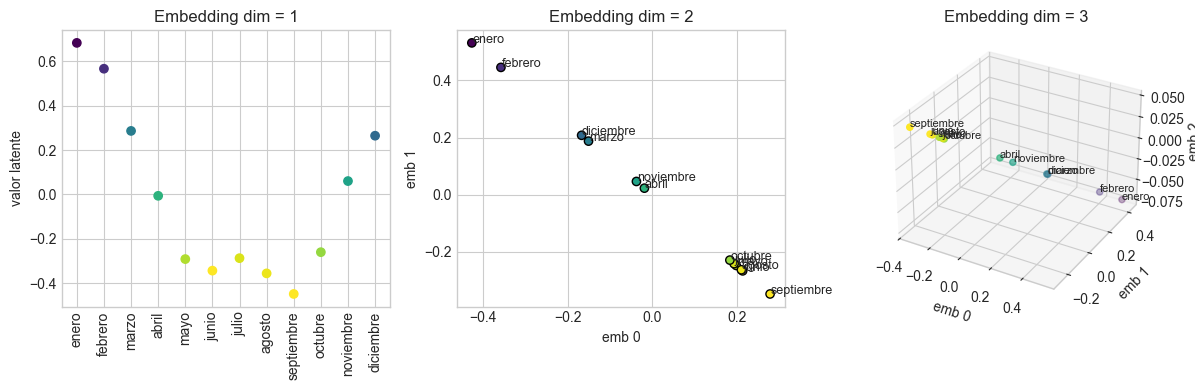

Pesos lineales - Experimento E - dim 1
  hum: -0.356766
  emb_0: -0.357676
  bias: 0.726690

Pesos lineales - Experimento E - dim 2
  hum: -0.300681
  emb_0: 0.252118
  emb_1: -0.314290
  bias: 0.757010

Pesos lineales - Experimento E - dim 3
  hum: -0.385900
  emb_0: -0.275601
  emb_1: -0.223091
  emb_2: 0.037539
  bias: 0.690817



In [14]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(np.arange(len(meses)), exp_dim1["emb_final"][:, 0], c=exp_dim1["summary"]["target_mean"], cmap="viridis")
plt.xticks(np.arange(len(meses)), meses, rotation=90)
plt.title("Embedding dim = 1")
plt.ylabel("valor latente")

plt.subplot(1, 3, 2)
emb2 = exp_dim2["emb_final"]
plt.scatter(emb2[:, 0], emb2[:, 1], c=exp_dim2["summary"]["target_mean"], cmap="viridis", edgecolor="black")
for i, mes in enumerate(meses):
    plt.text(emb2[i, 0] + 0.001, emb2[i, 1] + 0.001, mes, fontsize=9)
plt.title("Embedding dim = 2")
plt.xlabel("emb 0")
plt.ylabel("emb 1")

ax = plt.subplot(1, 3, 3, projection="3d")
emb3 = exp_dim3["emb_final"]
ax.scatter(emb3[:, 0], emb3[:, 1], emb3[:, 2], c=exp_dim3["summary"]["target_mean"], cmap="viridis")
for i, mes in enumerate(meses):
    ax.text(emb3[i, 0], emb3[i, 1], emb3[i, 2], mes, fontsize=8)
ax.set_title("Embedding dim = 3")
ax.set_xlabel("emb 0")
ax.set_ylabel("emb 1")
ax.set_zlabel("emb 2")

plt.tight_layout()
plt.show()

print_linear_weights(exp_dim1, "Experimento E - dim 1")
print_linear_weights(exp_dim2, "Experimento E - dim 2")
print_linear_weights(exp_dim3, "Experimento E - dim 3")